In [2]:
import numpy as np
import pandas as pd
from scipy import stats
from scipy.stats import hmean
import matplotlib.pyplot as plt
import matplotlib.transforms as mtransforms

In [3]:
plt.style.use('default')

In [4]:
dimension_groups = ['AS', 'AT', 'CE', 'CL', 'KN', 'MC', 'QL', 'SN', 'VO']

In [5]:
rescaling_coefficients_df = pd.read_csv("data/rescaling_coefficients.csv", index_col=0)
rescaling_coefficients_df = rescaling_coefficients_df[dimension_groups]

In [6]:
calibration_dict = {}

In [7]:
for dimension_group in dimension_groups:
    df = pd.read_csv(f"data/Violin_Plots_Means/{dimension_group}.txt", header=None)
    df[0] = df[0].apply(lambda x: round(x))
    calibration_dict[dimension_group] = (df[0].values, df[1].values)

In [8]:
# Sanity check : comparer les coefficients de régression obtenus sur les points récoltés par lecture graphique à ceux publiés + afficher le R^2
for dimension_group in dimension_groups:
    slope_read, intercept_read, r, _, _ = stats.linregress(calibration_dict[dimension_group][0], calibration_dict[dimension_group][1])
    print(f"dimension : {dimension_group}, r^2 : {r*r :.2f} \n slope_read : {slope_read : .2f}, slope_ref : {rescaling_coefficients_df[dimension_group]['Pente']}, intercept_read : {intercept_read : .2f} intercept_ref : {rescaling_coefficients_df[dimension_group]['Intercept']}")

dimension : AS, r^2 : 0.86 
 slope_read :  1.22, slope_ref : 1.24, intercept_read :  0.16 intercept_ref : 0.15
dimension : AT, r^2 : 0.12 
 slope_read :  0.47, slope_ref : 0.48, intercept_read :  2.53 intercept_ref : 2.55
dimension : CE, r^2 : 0.42 
 slope_read :  0.20, slope_ref : 0.2, intercept_read :  1.00 intercept_ref : 1.02
dimension : CL, r^2 : 0.98 
 slope_read :  0.50, slope_ref : 0.5, intercept_read :  0.27 intercept_ref : 0.27
dimension : KN, r^2 : 0.77 
 slope_read :  0.71, slope_ref : 0.71, intercept_read :  0.75 intercept_ref : 0.8
dimension : MC, r^2 : 0.64 
 slope_read :  0.83, slope_ref : 0.83, intercept_read :  0.46 intercept_ref : 0.5
dimension : QL, r^2 : 0.59 
 slope_read :  0.25, slope_ref : 0.24, intercept_read :  0.92 intercept_ref : 0.97
dimension : SN, r^2 : 0.71 
 slope_read :  0.10, slope_ref : 0.1, intercept_read :  1.91 intercept_ref : 1.95
dimension : VO, r^2 : 0.64 
 slope_read :  1.51, slope_ref : 1.5, intercept_read : -0.61 intercept_ref : -0.55


In [9]:
def piecewise_affine_scaler(calibration_dict, dimension_group, level):
    xs, ys = calibration_dict[dimension_group][0], calibration_dict[dimension_group][1]
    n = len(xs)
    pos = 0
    for i in range(n):
        if i < n-1 and level > xs[i]:
            pos = i
    # Si level est dans l'enveloppe convexe de xs, alors xs[pos] < level. Si level < min(xs), alors pos = 0 et level sera fitté avec les 2 premiers points. Si level > max(xs), alors pos = n-1 et level sera fitté avec les 2 derniers points
    slope = (ys[pos+1] - ys[pos])/(xs[pos+1] - xs[pos])
    intercept = ys[pos] - slope*xs[pos]
    return slope*level + intercept

In [10]:
def increasing_scaler(calibration_dict, dimension_group, level):
    xs, ys = calibration_dict[dimension_group][0], calibration_dict[dimension_group][1]
    n = len(xs)
    pos = 0
    for i in range(n):
        if i < n-1 and level > xs[i]:
            pos = i
    # Si level est dans l'enveloppe convexe de xs, alors xs[pos] < level. Si level < min(xs), alors pos = 0 et level sera fitté avec les 2 premiers points. Si level > max(xs), alors pos = n-1 et level sera fitté avec les 2 derniers points
    if ys[pos+1] >= ys[pos]:
        slope = (ys[pos+1] - ys[pos])/(xs[pos+1] - xs[pos])
        intercept = ys[pos] - slope*xs[pos]
    else :
        slope, intercept = 0, (ys[pos+1] + ys[pos])/2
    return slope*level + intercept

In [11]:
'''Lire les ability profiles, regrouper ceux du nature et les plus récents'''
nature_profiles_df = pd.read_csv("ability_profiles/ability_profiles_MaxAuxDiff=0_DupThresh=100.csv", index_col=0)
additional_profiles_df = pd.read_csv('data/additional_results_16June2026.csv', index_col=0)
ability_profiles_df = pd.concat([nature_profiles_df, additional_profiles_df], axis=0)
'''Collapser les ability profiles sur les groupes de dimensions du human scales'''
#On exploite la nomenclature des auteurs, dans laquelle chaque nom de groupe est constitué de deux lettres majuscules qui sont les deux premières lettres des dimensions qui le constituent
#Une exception à traiter à part : SNs
dimensions = list(ability_profiles_df.columns)
for dimension_group in dimension_groups:
    components = [dimension for dimension in dimensions if dimension[:2] == dimension_group]
    if len(components) >= 2:
        ability_profiles_df[dimension_group] = ability_profiles_df[components].apply(hmean, axis=1)
ability_profiles_df['SN'] = ability_profiles_df['SNs'].copy()
reduced_profiles_columns = list(dimension_groups)
reduced_profiles_df = ability_profiles_df[reduced_profiles_columns].copy()

In [12]:
'''Changement d'échelle affine'''
rescaling_coefficients_df = pd.read_csv("data/rescaling_coefficients.csv")
rescaled_profiles_affine_df = reduced_profiles_df.copy()
for dimension_group in dimension_groups:
    rescaled_profiles_affine_df[dimension_group] = rescaled_profiles_affine_df[dimension_group].apply(
        lambda x: rescaling_coefficients_df[dimension_group].iloc[0] * x +
                  rescaling_coefficients_df[dimension_group].iloc[1])
rescaled_profiles_affine_df = rescaled_profiles_affine_df[dimension_groups]
release_dates_df = pd.read_csv("data/release_dates.csv", index_col=0)
release_dates_df = release_dates_df[['Date de sortie']]
release_dates_df['Date de sortie'] = pd.to_datetime(release_dates_df['Date de sortie'])
rescaled_profiles_affine_df['Date'] = release_dates_df['Date de sortie']

C:\Users\Michel\AppData\Local\Temp\ipykernel_39028\1121516860.py:11: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  release_dates_df['Date de sortie'] = pd.to_datetime(release_dates_df['Date de sortie'])


In [13]:
'''Changement d'échelle affine par morceaux'''
rescaling_coefficients_df = pd.read_csv("data/rescaling_coefficients.csv")
rescaled_profiles_piecewise_df = reduced_profiles_df.copy()
for dimension_group in dimension_groups:
    rescaled_profiles_piecewise_df[dimension_group] = rescaled_profiles_piecewise_df[dimension_group].apply(
        lambda x: piecewise_affine_scaler(calibration_dict, dimension_group, x))
rescaled_profiles_piecewise_df = rescaled_profiles_piecewise_df[dimension_groups]
release_dates_df = pd.read_csv("data/release_dates.csv", index_col=0)
release_dates_df = release_dates_df[['Date de sortie']]
release_dates_df['Date de sortie'] = pd.to_datetime(release_dates_df['Date de sortie'])
rescaled_profiles_piecewise_df['Date'] = release_dates_df['Date de sortie']

C:\Users\Michel\AppData\Local\Temp\ipykernel_39028\4029121501.py:10: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  release_dates_df['Date de sortie'] = pd.to_datetime(release_dates_df['Date de sortie'])


In [14]:
'''Changement d'échelle croissant'''
rescaling_coefficients_df = pd.read_csv("data/rescaling_coefficients.csv")
rescaled_profiles_increasing_df = reduced_profiles_df.copy()
for dimension_group in dimension_groups:
    rescaled_profiles_increasing_df[dimension_group] = rescaled_profiles_increasing_df[dimension_group].apply(
        lambda x: increasing_scaler(calibration_dict, dimension_group, x))
rescaled_profiles_increasing_df = rescaled_profiles_increasing_df[dimension_groups]
release_dates_df = pd.read_csv("data/release_dates.csv", index_col=0)
release_dates_df = release_dates_df[['Date de sortie']]
release_dates_df['Date de sortie'] = pd.to_datetime(release_dates_df['Date de sortie'])
rescaled_profiles_increasing_df['Date'] = release_dates_df['Date de sortie']

C:\Users\Michel\AppData\Local\Temp\ipykernel_39028\1921316071.py:10: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  release_dates_df['Date de sortie'] = pd.to_datetime(release_dates_df['Date de sortie'])


In [15]:
def frontier_indices(xs, ys):  #Vérifier le traitement des cas d'égalité. Il faudrait idéalement contrôler si plusieurs modèles sortis le même jour et dépassant ceux qui les précèdent sont tous frontière, ou seulement le meilleur d'entre eux. La version actuelle du code ne me semble pas donner de garantie à ce sujet.
    assert len(xs) == len(ys)
    sorted_order = np.argsort(xs)
    current_max = -np.inf
    front_original_indices = []
    for idx in sorted_order:
        if ys[idx] > current_max:
            current_max = ys[idx]
            front_original_indices.append(idx)
    return front_original_indices


corporations = {'Babbage-002': 'OpenAI',
                'Davinci-002': 'OpenAI',
                'GPT-3.5-Turbo': 'OpenAI',
                'GPT-4o': 'OpenAI',
                'OpenAI o1-mini': 'OpenAI',
                'OpenAI o1': 'OpenAI',
                'LLaMA-3.2-1B-Instruct': 'Meta',
                'LLaMA-3.2-3B-Instruct': 'Meta',
                'LLaMA-3.2-11B-Instruct': 'Meta',
                'LLaMA-3.2-90B-Instruct': 'Meta',
                'LLaMA-3.1-405B-Instruct': 'Meta',
                'DK-R1-Dist-Qwen-1.5B': 'Qwen',
                'DK-R1-Dist-Qwen-7B': 'Qwen',
                'DK-R1-Dist-Qwen-14B': 'Qwen',
                'DK-R1-Dist-Qwen-32B': 'Qwen',
                'Gemini-2.5-Flash': 'Google',
                'Gemini-3.1-Flash': 'Google',
                'Gemini-3.1-Pro': 'Google',
                'LLaMA-4-17B-128E': 'Meta',
                'GPT-5.2-Chat': 'OpenAI',
                'OpenAI o3-mini': 'OpenAI'}

"""corpo_color_map = {'OpenAI': 'r',
                   'Meta': 'b',
                   'Qwen': 'g',
                   'Google': 'purple'}"""

"corpo_color_map = {'OpenAI': 'r',\n                   'Meta': 'b',\n                   'Qwen': 'g',\n                   'Google': 'purple'}"

In [16]:
def rainbow_line(ax, x, y, parts, fontsize=13):
    """parts : liste de tuples (texte, couleur), dessinés côte à côte à partir de (x, y) en coords axes."""
    t = ax.transAxes
    last = None
    for s, c in parts:
        last = ax.text(x, y, s, color=c, fontsize=fontsize,
                        va='top', ha='left', transform=t, zorder=5)
        last.draw(ax.figure.canvas.get_renderer())
        ex = last.get_window_extent()
        t = mtransforms.offset_copy(last.get_transform(), x=ex.width, units='dots')
    return last

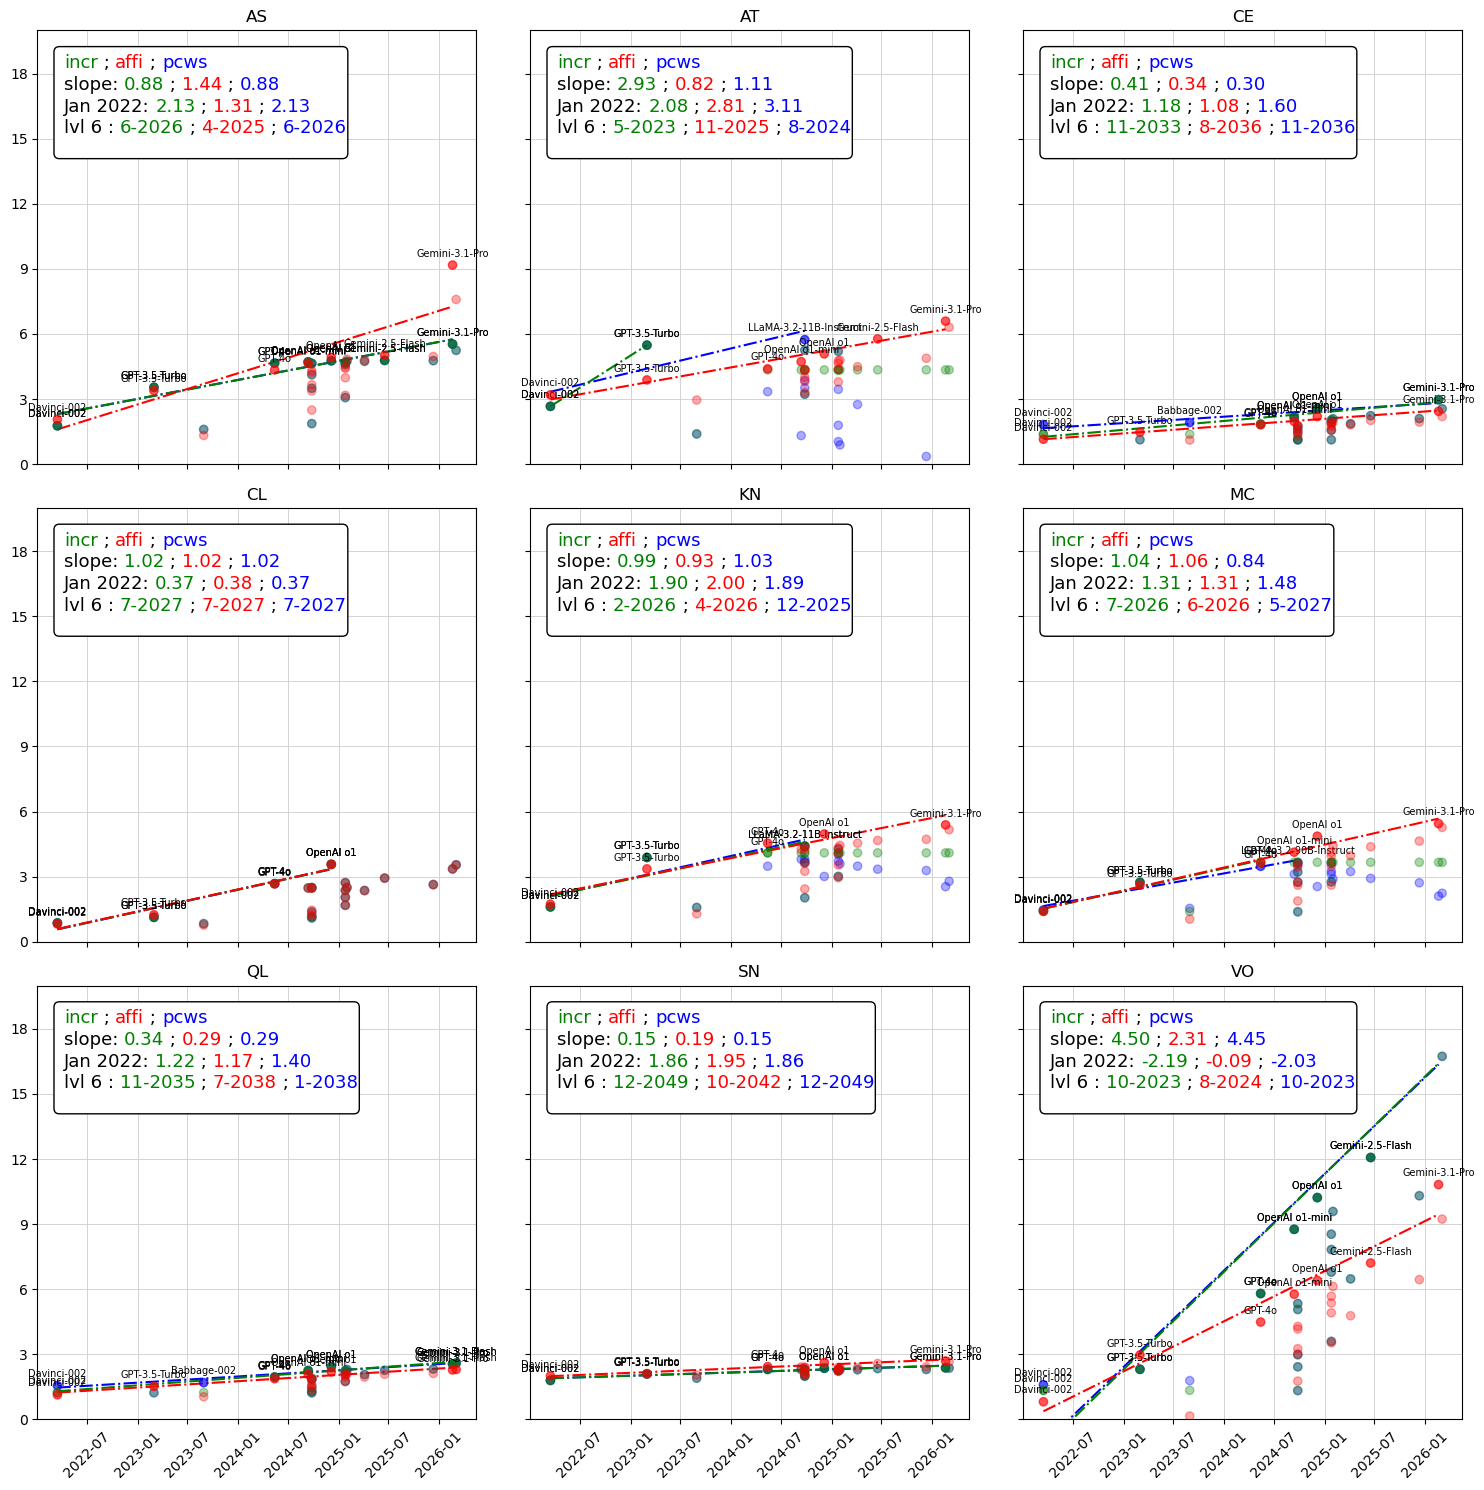

In [17]:
fig, axs = plt.subplots(3, 3, figsize=(15, 15), sharex=True, sharey=True)
release_dates = rescaled_profiles_affine_df['Date'].values
model_names = list(rescaled_profiles_affine_df.index)
xs = release_dates

for i in range(3):
    for j in range(3):
        """Ci-dessous : partie piecewise"""
        ax = axs[i][j]
        ys = rescaled_profiles_piecewise_df[dimension_groups[3*i+j]].values
        front = set(frontier_indices(xs, ys))
        alphas, xsfront, ysfront = [], [], []
        for k in range(len(xs)):
            if k in front:
                alphas.append(0.66)
                xsfront.append(xs[k])
                ysfront.append(ys[k])
            else :
                alphas.append(0.33)
        xsfront_years_since_2022 = [(x - pd.to_datetime("2022-01-01")).total_seconds()/(3600*24*365.25) for x in xsfront]

        ax.scatter(xs, ys, zorder=3, c='b', alpha=alphas)

        # Labels frontière
        for k in front:
            ax.annotate(
                model_names[k], (xs[k], ys[k]),
                textcoords="offset points", xytext=(0, 6),
                ha='center', fontsize=7
            )

        regression = stats.linregress(xsfront_years_since_2022, ysfront, alternative='greater')
        slope_piecewise, intercept_piecewise, r_piecewise, p_value_piecewise, slope_stderr_piecewise = regression
        intercept_stderr = regression.intercept_stderr
        x_0, x_1 = (min(xsfront) - pd.to_datetime("2022-01-01")).total_seconds()/(3600*24*365.25), (max(xsfront) - pd.to_datetime("2022-01-01")).total_seconds()/(3600*24*365.25)
        y_0, y_1 = intercept_piecewise + slope_piecewise * x_0, intercept_piecewise + slope_piecewise * x_1
        ax.plot([min(xsfront), max(xsfront)], [y_0, y_1], ls='dashdot', color='b')

        """Ci-dessous : partie increasing"""
        ys = rescaled_profiles_increasing_df[dimension_groups[3*i+j]].values
        front = set(frontier_indices(xs, ys))
        alphas, xsfront, ysfront = [], [], []
        for k in range(len(xs)):
            if k in front:
                alphas.append(0.66)
                xsfront.append(xs[k])
                ysfront.append(ys[k])
            else :
                alphas.append(0.33)
        xsfront_years_since_2022 = [(x - pd.to_datetime("2022-01-01")).total_seconds()/(3600*24*365.25) for x in xsfront]

        ax.scatter(xs, ys, zorder=3, c='g', alpha=alphas)

        # Labels frontière
        for k in front:
            ax.annotate(
                model_names[k], (xs[k], ys[k]),
                textcoords="offset points", xytext=(0, 6),
                ha='center', fontsize=7
            )

        regression = stats.linregress(xsfront_years_since_2022, ysfront, alternative='greater')
        slope_increasing, intercept_increasing, r_increasing, p_value_increasing, slope_stderr_increasing = regression
        intercept_stderr = regression.intercept_stderr
        x_0, x_1 = (min(xsfront) - pd.to_datetime("2022-01-01")).total_seconds()/(3600*24*365.25), (max(xsfront) - pd.to_datetime("2022-01-01")).total_seconds()/(3600*24*365.25)
        y_0, y_1 = intercept_increasing + slope_increasing * x_0, intercept_increasing + slope_increasing * x_1
        ax.plot([min(xsfront), max(xsfront)], [y_0, y_1], ls='dashdot', color='g')

        """Ci-dessous : partie affine"""
        ys = rescaled_profiles_affine_df[dimension_groups[3*i+j]].values
        front = set(frontier_indices(xs, ys))
        alphas, xsfront, ysfront = [], [], []
        for k in range(len(xs)):
            if k in front:
                alphas.append(0.66)
                xsfront.append(xs[k])
                ysfront.append(ys[k])
            else :
                alphas.append(0.33)
        xsfront_years_since_2022 = [(x - pd.to_datetime("2022-01-01")).total_seconds()/(3600*24*365.25) for x in xsfront]

        ax.scatter(xs, ys, zorder=3, c='r', alpha=alphas)

        # Labels frontière
        for k in front:
            ax.annotate(
                model_names[k], (xs[k], ys[k]),
                textcoords="offset points", xytext=(0, 6),
                ha='center', fontsize=7
            )

        regression = stats.linregress(xsfront_years_since_2022, ysfront, alternative='greater')
        slope_affine, intercept_affine, r_affine, p_value_affine, slope_stderr_affine = regression
        intercept_stderr = regression.intercept_stderr
        x_0, x_1 = (min(xsfront) - pd.to_datetime("2022-01-01")).total_seconds()/(3600*24*365.25), (max(xsfront) - pd.to_datetime("2022-01-01")).total_seconds()/(3600*24*365.25)
        y_0, y_1 = intercept_affine + slope_affine * x_0, intercept_affine + slope_affine * x_1
        ax.plot([min(xsfront), max(xsfront)], [y_0, y_1], ls='dashdot', color='r')

        x_millionth_increasing = (6-intercept_increasing)/slope_increasing
        date_millionth_increasing = pd.to_datetime("2022-01-01") + pd.to_timedelta(x_millionth_increasing*365.25, unit='D')
        x_millionth_affine = (6-intercept_affine)/slope_affine
        date_millionth_affine = pd.to_datetime("2022-01-01") + pd.to_timedelta(x_millionth_affine*365.25, unit='D')
        x_millionth_piecewise = (6-intercept_piecewise)/slope_piecewise
        date_millionth_piecewise = pd.to_datetime("2022-01-01") + pd.to_timedelta(x_millionth_piecewise*365.25, unit='D')

        # Attention : les cas où la pente est nulle ou strictement négative ne sont pas gérés ici, et donneraient respectivement une erreur ou un résultat qu'il faut interpréter différemment du cas où la pente est positive. De même, le cas où la pente est inférieure à son incertitude-type pose problème.

        # Boîte blanche de fond : on réutilise l'astuce du texte invisible
        # pour que le bbox ait la bonne taille (3 lignes, même police)
        stats_text = (
            "incr ; affi ; pcws\n"
            f"slope: {slope_increasing:.2f} ; {slope_affine:.2f} ;  {slope_piecewise:.2f}\n"
            f"Jan 2022: {intercept_increasing:.2f} ; {intercept_affine:.2f} ;  {intercept_piecewise:.2f}\n"  # bug corrigé
            f"lvl 6 : {date_millionth_increasing.month}-{date_millionth_increasing.year} ; "
            f"{date_millionth_affine.month}-{date_millionth_affine.year} ; "
            f"{date_millionth_piecewise.month}-{date_millionth_piecewise.year}\n"
        )
        ax.text(0.05, 0.95, stats_text, transform=ax.transAxes, fontsize=13,
                va='top', ha='left', color='none',
                bbox=dict(boxstyle='round', facecolor='w', alpha=1), zorder=4)

        # Texte coloré par-dessus, ligne par ligne (vert=increasing, rouge=affine, bleu=piecewise)
        rainbow_line(ax, 0.06, 0.945, [
            ("incr", 'g'), (" ; ", 'black'),
            ("affi", 'r'), (" ; ", 'black'),
            ("pcws", 'b'),
        ])
        rainbow_line(ax, 0.06, 0.895, [   # décalé de 0.945 → 0.895
            ("slope: ", 'black'),
            (f"{slope_increasing:.2f}", 'g'), (" ; ", 'black'),
            (f"{slope_affine:.2f}", 'r'), (" ; ", 'black'),
            (f"{slope_piecewise:.2f}", 'b'),
        ])
        rainbow_line(ax, 0.06, 0.845, [   # décalé de 0.895 → 0.845
            ("Jan 2022: ", 'black'),
            (f"{intercept_increasing:.2f}", 'g'), (" ; ", 'black'),
            (f"{intercept_affine:.2f}", 'r'), (" ; ", 'black'),
            (f"{intercept_piecewise:.2f}", 'b'),
        ])
        rainbow_line(ax, 0.06, 0.795, [   # décalé de 0.845 → 0.795
            ("lvl 6 : ", 'black'),
            (f"{date_millionth_increasing.month}-{date_millionth_increasing.year}", 'g'), (" ; ", 'black'),
            (f"{date_millionth_affine.month}-{date_millionth_affine.year}", 'r'), (" ; ", 'black'),
            (f"{date_millionth_piecewise.month}-{date_millionth_piecewise.year}", 'b'),
        ])

        ax.set_title(dimension_groups[3*i+j])

        # Grille gris clair
        ax.grid(True, color='lightgrey', linewidth=0.7, zorder=0)
        ax.set_axisbelow(True)

        # Rotation xticks
        ax.tick_params(axis='x', rotation=45)
        ax.set_yticks([-9, -6, -3, 0, 3, 6, 9 ,12, 15, 18])
        ax.set_ylim([0,20])

plt.tight_layout()
plt.show()

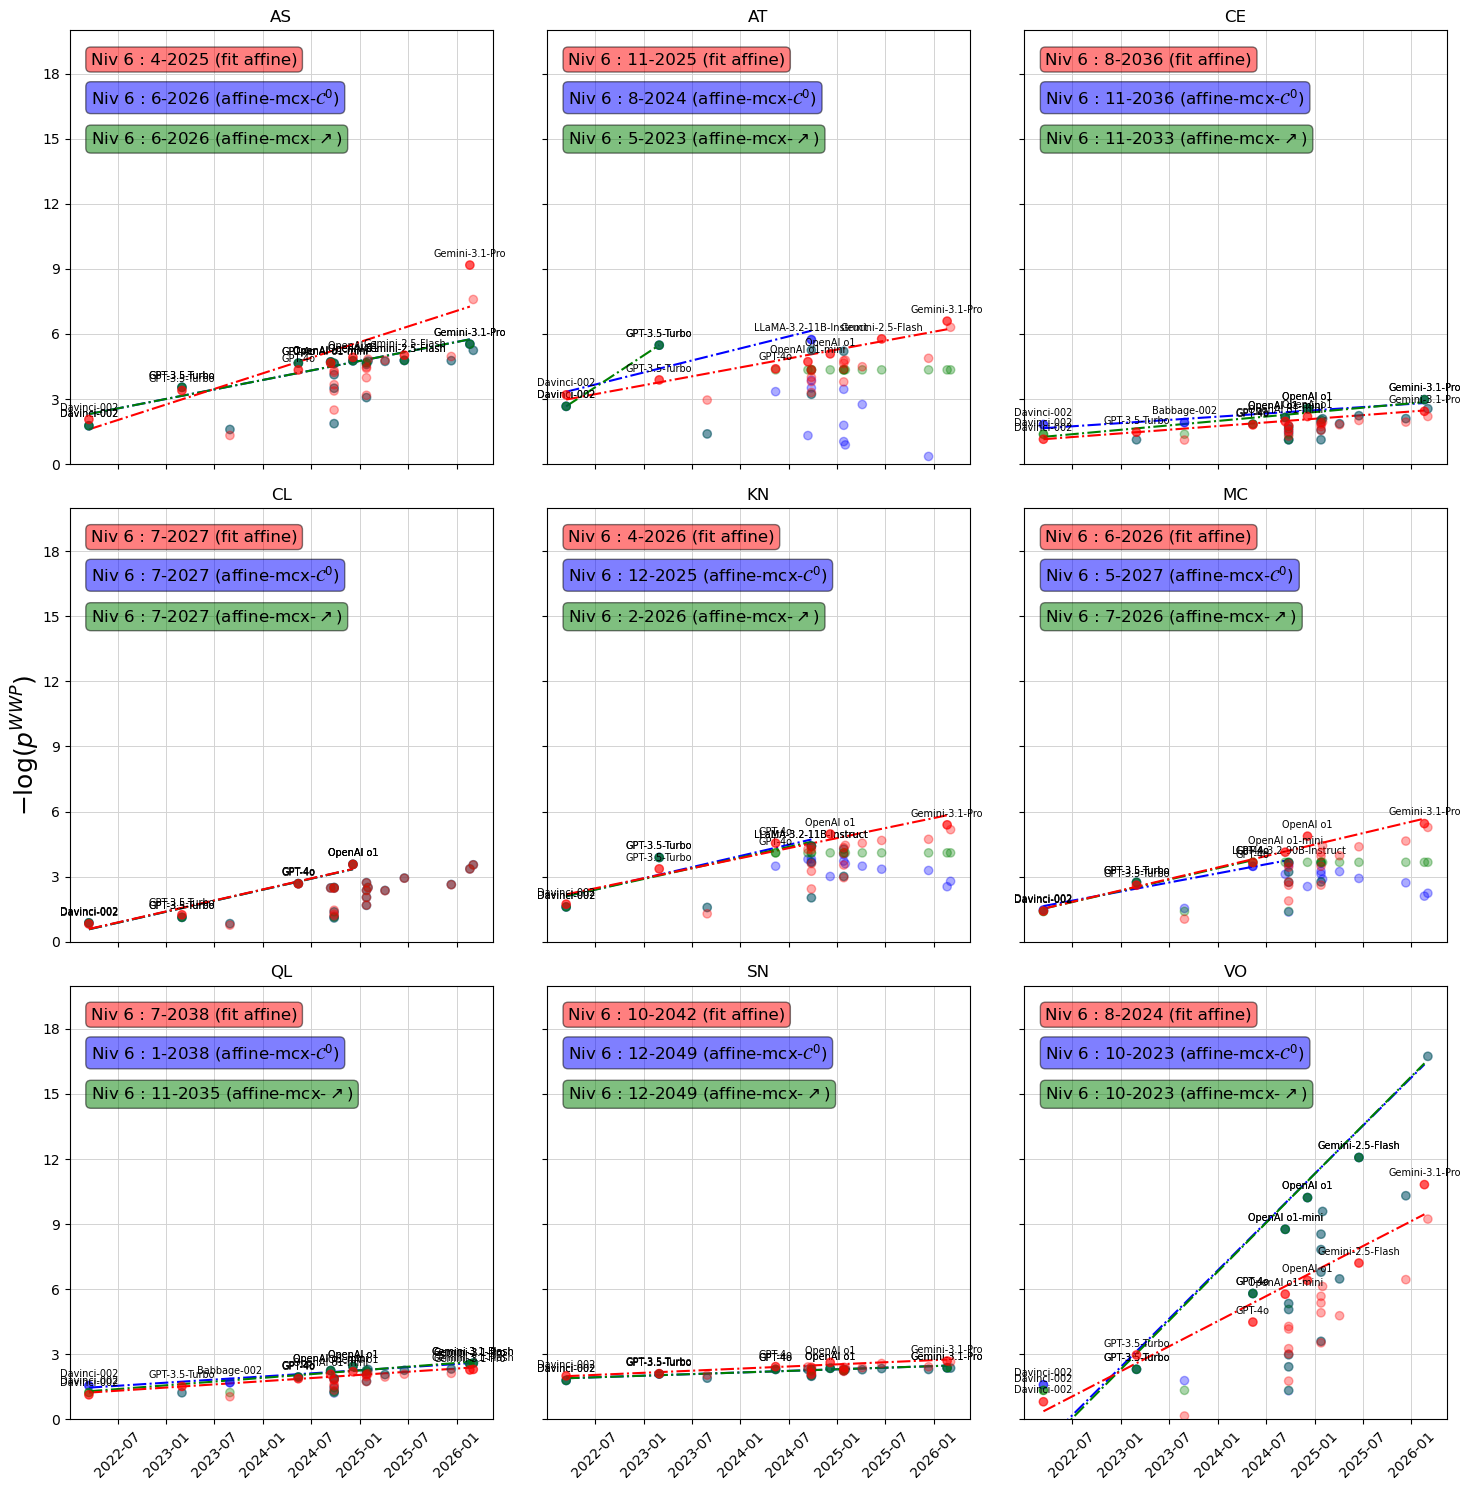

In [28]:
fig, axs = plt.subplots(3, 3, figsize=(15, 15), sharex=True, sharey=True)
release_dates = rescaled_profiles_affine_df['Date'].values
model_names = list(rescaled_profiles_affine_df.index)
xs = release_dates

for i in range(3):
    for j in range(3):
        """Ci-dessous : partie piecewise"""
        ax = axs[i][j]
        ys = rescaled_profiles_piecewise_df[dimension_groups[3 * i + j]].values
        front = set(frontier_indices(xs, ys))
        alphas, xsfront, ysfront = [], [], []
        for k in range(len(xs)):
            if k in front:
                alphas.append(0.66)
                xsfront.append(xs[k])
                ysfront.append(ys[k])
            else:
                alphas.append(0.33)
        xsfront_years_since_2022 = [(x - pd.to_datetime("2022-01-01")).total_seconds() / (3600 * 24 * 365.25) for x in
                                    xsfront]

        ax.scatter(xs, ys, zorder=3, c='b', alpha=alphas)

        for k in front:
            ax.annotate(
                model_names[k], (xs[k], ys[k]),
                textcoords="offset points", xytext=(0, 6),
                ha='center', fontsize=7
            )

        regression = stats.linregress(xsfront_years_since_2022, ysfront, alternative='greater')
        slope_piecewise, intercept_piecewise, r_piecewise, p_value_piecewise, slope_stderr_piecewise = regression
        intercept_stderr = regression.intercept_stderr
        x_0, x_1 = (min(xsfront) - pd.to_datetime("2022-01-01")).total_seconds() / (3600 * 24 * 365.25), (
                    max(xsfront) - pd.to_datetime("2022-01-01")).total_seconds() / (3600 * 24 * 365.25)
        y_0, y_1 = intercept_piecewise + slope_piecewise * x_0, intercept_piecewise + slope_piecewise * x_1
        ax.plot([min(xsfront), max(xsfront)], [y_0, y_1], ls='dashdot', color='b')

        """Ci-dessous : partie increasing"""
        ys = rescaled_profiles_increasing_df[dimension_groups[3 * i + j]].values
        front = set(frontier_indices(xs, ys))
        alphas, xsfront, ysfront = [], [], []
        for k in range(len(xs)):
            if k in front:
                alphas.append(0.66)
                xsfront.append(xs[k])
                ysfront.append(ys[k])
            else:
                alphas.append(0.33)
        xsfront_years_since_2022 = [(x - pd.to_datetime("2022-01-01")).total_seconds() / (3600 * 24 * 365.25) for x in
                                    xsfront]

        ax.scatter(xs, ys, zorder=3, c='g', alpha=alphas)

        for k in front:
            ax.annotate(
                model_names[k], (xs[k], ys[k]),
                textcoords="offset points", xytext=(0, 6),
                ha='center', fontsize=7
            )

        regression = stats.linregress(xsfront_years_since_2022, ysfront, alternative='greater')
        slope_increasing, intercept_increasing, r_increasing, p_value_increasing, slope_stderr_increasing = regression
        intercept_stderr = regression.intercept_stderr
        x_0, x_1 = (min(xsfront) - pd.to_datetime("2022-01-01")).total_seconds() / (3600 * 24 * 365.25), (
                    max(xsfront) - pd.to_datetime("2022-01-01")).total_seconds() / (3600 * 24 * 365.25)
        y_0, y_1 = intercept_increasing + slope_increasing * x_0, intercept_increasing + slope_increasing * x_1
        ax.plot([min(xsfront), max(xsfront)], [y_0, y_1], ls='dashdot', color='g')

        """Ci-dessous : partie affine"""
        ys = rescaled_profiles_affine_df[dimension_groups[3 * i + j]].values
        front = set(frontier_indices(xs, ys))
        alphas, xsfront, ysfront = [], [], []
        for k in range(len(xs)):
            if k in front:
                alphas.append(0.66)
                xsfront.append(xs[k])
                ysfront.append(ys[k])
            else:
                alphas.append(0.33)
        xsfront_years_since_2022 = [(x - pd.to_datetime("2022-01-01")).total_seconds() / (3600 * 24 * 365.25) for x in
                                    xsfront]

        ax.scatter(xs, ys, zorder=3, c='r', alpha=alphas)

        for k in front:
            ax.annotate(
                model_names[k], (xs[k], ys[k]),
                textcoords="offset points", xytext=(0, 6),
                ha='center', fontsize=7
            )

        regression = stats.linregress(xsfront_years_since_2022, ysfront, alternative='greater')
        slope_affine, intercept_affine, r_affine, p_value_affine, slope_stderr_affine = regression
        intercept_stderr = regression.intercept_stderr
        x_0, x_1 = (min(xsfront) - pd.to_datetime("2022-01-01")).total_seconds() / (3600 * 24 * 365.25), (
                    max(xsfront) - pd.to_datetime("2022-01-01")).total_seconds() / (3600 * 24 * 365.25)
        y_0, y_1 = intercept_affine + slope_affine * x_0, intercept_affine + slope_affine * x_1
        ax.plot([min(xsfront), max(xsfront)], [y_0, y_1], ls='dashdot', color='r')

        x_millionth_increasing = (6 - intercept_increasing) / slope_increasing
        date_millionth_increasing = pd.to_datetime("2022-01-01") + pd.to_timedelta(x_millionth_increasing * 365.25,
                                                                                   unit='D')
        x_millionth_affine = (6 - intercept_affine) / slope_affine
        date_millionth_affine = pd.to_datetime("2022-01-01") + pd.to_timedelta(x_millionth_affine * 365.25, unit='D')
        x_millionth_piecewise = (6 - intercept_piecewise) / slope_piecewise
        date_millionth_piecewise = pd.to_datetime("2022-01-01") + pd.to_timedelta(x_millionth_piecewise * 365.25,
                                                                                  unit='D')

        # Attention : les cas où la pente est nulle ou strictement négative ne sont pas gérés ici,
        # et donneraient respectivement une erreur ou un résultat à interpréter différemment.
        # De même, une pente inférieure à son incertitude-type pose problème.

        text_affine = f"Niv 6 : {date_millionth_affine.month}-{date_millionth_affine.year} (fit affine)"
        text_piecewise = f"Niv 6 : {date_millionth_piecewise.month}-{date_millionth_piecewise.year} (affine-mcx-" + r"$\mathcal{C}^{0}$" + ")"
        text_increasing = f"Niv 6 : {date_millionth_increasing.month}-{date_millionth_increasing.year} (affine-mcx-" + r"$\nearrow$" + ")"

        ax.text(0.05, 0.95, text_affine, transform=ax.transAxes,
                fontsize=12, va='top', ha='left',
                bbox=dict(boxstyle='round', facecolor='r', alpha=0.5),
                color='black')

        ax.text(0.05, 0.87, text_piecewise, transform=ax.transAxes,
                fontsize=12, va='top', ha='left',
                bbox=dict(boxstyle='round', facecolor='b', alpha=0.5),
                color='black')

        ax.text(0.05, 0.77, text_increasing, transform=ax.transAxes,
                fontsize=12, va='top', ha='left',
                bbox=dict(boxstyle='round', facecolor='g', alpha=0.5),
                color='black')

        ax.set_title(dimension_groups[3 * i + j])

        ax.grid(True, color='lightgrey', linewidth=0.7, zorder=0)
        ax.set_axisbelow(True)

        ax.tick_params(axis='x', rotation=45)
        ax.set_yticks([-9, -6, -3, 0, 3, 6, 9, 12, 15, 18])
        ax.set_ylim([0, 20])

fig.supylabel(r'$-\text{log}(p^{WWP})''$', fontsize=18)
plt.tight_layout()
plt.show()